### HIRESAFE ANALYTICS :

In [ ]:
# Installing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading the dataset

df = pd.read_csv("fake_job_postings 2.csv")

#### DATA UNDERSTANDING

#### Basic Structure Check

In [ ]:
df.shape              # Rows & columns

(17880, 18)

In [ ]:
df.columns #column names

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'country', 'min_salary', 'max_salary', 'avg_salary',
       'salary_avg', 'has_company_profile', 'desc_len'],
      dtype='object')

In [ ]:
df.info() # Display comprehensive information about the DataFrame including data types, non-null counts, and memory usage

<class 'pandas.core.frame.DataFrame'>
Index: 1732 entries, 553 to 17831
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               1732 non-null   int64  
 1   title                1732 non-null   object 
 2   location             1732 non-null   object 
 3   department           1732 non-null   object 
 4   salary_range         1732 non-null   object 
 5   company_profile      1732 non-null   object 
 6   description          1732 non-null   object 
 7   requirements         1732 non-null   object 
 8   benefits             1732 non-null   object 
 9   telecommuting        1732 non-null   int64  
 10  has_company_logo     1732 non-null   int64  
 11  has_questions        1732 non-null   int64  
 12  employment_type      1732 non-null   object 
 13  required_experience  1732 non-null   object 
 14  required_education   1732 non-null   object 
 15  industry             1732 non-null   obj

In [ ]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


#### DATA PREPROCESSING

#### Column Categorization

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols #numerical columns

Index(['job_id', 'telecommuting', 'has_company_logo', 'has_questions',
       'fraudulent'],
      dtype='object')

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols # categorical columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function'],
      dtype='object')

#### Handle missing values

In [ ]:
missing_data = pd.DataFrame({ # Create a DataFrame to analyze missing data in the dataset
    'Missing Values': df.isnull().sum(), # Count the number of missing (null) values for each column
    'Percentage': (df.isnull().sum()/len(df))*100 #'Percentage': (df.isnull().sum()/len(df))*100
})

missing_data

,Missing Values,Percentage
job_id,0,0.000000
title,0,0.000000
location,0,0.000000
department,0,0.000000
salary_range,0,0.000000
company_profile,0,0.000000
description,0,0.000000
requirements,0,0.000000
benefits,0,0.000000
telecommuting,0,0.000000


In [ ]:
import string
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [ ]:
df.shape

(17880, 18)

In [ ]:
# Fill NaN values with blank space
# inplace=true to make this change in the dataset permanent
df.fillna(' ', inplace=True)
print(df)

       job_id                                              title  \
0           1                                   Marketing Intern   
1           2          Customer Service - Cloud Video Production   
2           3            Commissioning Machinery Assistant (CMA)   
3           4                  Account Executive - Washington DC   
4           5                                Bill Review Manager   
...       ...                                                ...   
17875   17876                   Account Director - Distribution    
17876   17877                                 Payroll Accountant   
17877   17878  Project Cost Control Staff Engineer - Cost Con...   
17878   17879                                   Graphic Designer   
17879   17880                         Web Application Developers   

                   location   department salary_range  \
0          US, NY, New York    Marketing                
1            NZ, , Auckland      Success                
2           

#### Feature Extraction

In [ ]:
#Create independent and Dependent Features
columns = df.columns.tolist()
# Filter the columns to remove data we do not want
columns = [c for c in columns if c not in ["fraudulent"]]
# Store the variable we are predicting
target = "fraudulent"
# Define a random state
state = np.random.RandomState(42)
X = df[columns]
Y = df["fraudulent"]
X_outliers = state.uniform(low=0, high=1, size=(X.shape[0], X.shape[1]))
# Print the shapes of X & Y
print(X.shape)
print(Y.shape)
from imblearn.under_sampling import RandomUnderSampler

under_sampler = RandomUnderSampler()
X_res, y_res = under_sampler.fit_resample(X, Y)

df1 = pd.DataFrame(X_res)

df3 = pd.DataFrame(y_res)

# the default behaviour is join='outer'
# inner join

result = pd.concat([df1, df3], axis=1, join='inner')
display(result)
df=result;


(17880, 17)
(17880,)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
553,554,Misc Applications,,,,"We're an emerging technology agency, and we bu...",Candidates that have applied to MM through var...,,,0,1,0,,,,,,0
8390,8391,Telemarketers Needed,"US, CA, Los Angeles",,,We are a digital marketing agency with an emph...,We are seeking experienced telemarketers only....,Backgrounds in these areas work well in this p...,Flexible ShiftsWorld Class Training!Pay Twice ...,0,1,1,Full-time,Associate,High School or equivalent,Marketing and Advertising,Sales,0
2065,2066,Managing Director,"CA, BC, Vancouver",,,Pardon Services Canada is a national legal ser...,"Pardon Services Canada, established in 1989, i...",Experience: At least five years operations man...,,0,1,1,,,,,,0
16098,16099,Digital Designer for a Venture Capital Company,"GB, LND, London",,28000-35000,"Based in Hoxton, London, Forward Partners are ...",Forward Partners is an ecommerce investment st...,THE ROLETo work closely with the Head of Produ...,,0,1,0,Full-time,Associate,Unspecified,Internet,Art/Creative,0
9020,9021,Front-End Developer,"IT, 25, Milano",Development,25000-31000,we are a digital creative studio focused on UX...,Moze is looking for talented developers to del...,3+ years of relevant work experience.Deep know...,MacBook Air.Workstation desk and meeting rooms...,0,1,1,Full-time,Mid-Senior level,Unspecified,Information Technology and Services,Information Technology,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17827,17828,Student Positions Part-Time and Full-Time.,"US, CA, Los Angeles",,,,Student Positions Part-Time and Full-Time.You ...,,,0,0,0,Part-time,,,,,1
17828,17829,Sales Associate,"AU, NSW, Sydney",Sales and Marketing,,,LEARN TO EARN AN EXECUTIVE LEVEL INCOMEFULL TR...,What You Can Do. • Have the potential to earn ...,Who We Are We are a Global Leadership Developm...,0,0,1,,,,,,1
17829,17830,Android Developer,"PL, MZ, Warsaw",,,,inFullMobile Sp. z o.o. is a mobile software d...,• A proven track record in Android / JAVA proj...,attractive salary (adequate to the candidate s...,0,0,0,,,,,,1
17830,17831,Payroll Clerk,"US, NY, New York",,,,JOB DESCRIPTIONWe are seeking a full time payr...,JOB REQUIREMENTS• High school diploma or eq...,We offer a competitive salary and benefits pac...,0,0,0,Full-time,,,Apparel & Fashion,Accounting/Auditing,1


### Basic Questions

In [ ]:
# Count of total job postings
# Execution Code
df.shape[0]
total_jobs = df.shape[0]
print("Total Job Postings:", total_jobs)

Total Job Postings: 1732


In [ ]:
#Count of real jobs vs fake jobs
# Query
df['fraudulent'].value_counts()
# Execution Code
job_counts = df['fraudulent'].value_counts()

print("Real Jobs:", job_counts[0])
print("Fake Jobs:", job_counts[1])

Real Jobs: 866
Fake Jobs: 866


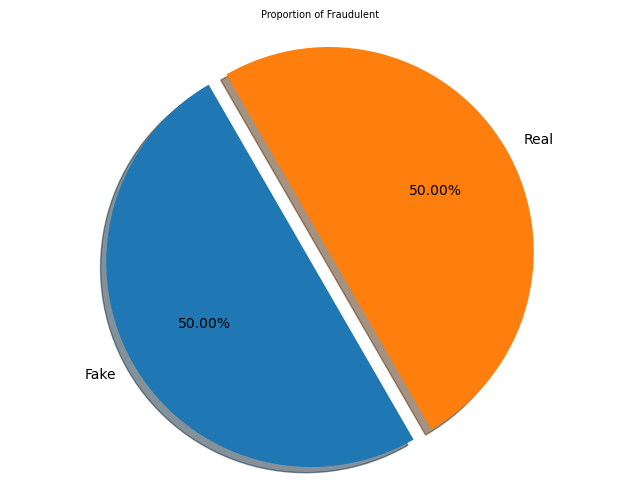

In [ ]:
# Checking for distribution of class label(percentages belonging to real class and percentages belonging to fraud class)
 # in the data 1 indicates fraud post
 # 0 indicating real post
 # Plotting pie chart for the data
 # function of Explode function: how the portion will appear (to understand change explode=(0,0.5))

labels = 'Fake', 'Real'
sizes = [df.fraudulent[df['fraudulent']== 1].count(), df.fraudulent[df['fraudulent']== 0].count()]
explode = (0, 0.1)
fig1, ax1 = plt.subplots(figsize=(8, 6)) #size of the pie chart
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.2f%%',
        shadow=True, startangle=120) #autopct %1.2f%% for 2 digit precision
ax1.axis('equal')
plt.title("Proportion of Fraudulent", size = 7)
plt.show()

In [ ]:
# this will give unique country values
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [ ]:
# we will try to see which country is posting most of the jobs
# Visualize job postings by countries
# we will use the location column for visualizing this data
# In location data is of type (country_name,state,city)
# we neeed to know the country wise data

def split(location):
    l = location.split(',')
    return l[0]

df['country'] = df.location.apply(split)
df['country']


553        
8390     US
2065     CA
16098    GB
9020     IT
         ..
17827    US
17828    AU
17829    PL
17830    US
17831    US
Name: country, Length: 1732, dtype: object

In [ ]:
# this will give unique country values
df['country'].nunique()

47

In [ ]:
# Missing Values Per Column
# Query
df.isnull().sum()
# Execution Code
missing_values = df.isnull().sum()

print(missing_values)

job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
country                0
dtype: int64


In [ ]:
# Duplicate Entries Count
# Query
df.duplicated().sum()
# Execution Code
duplicate_count = df.duplicated().sum()

print("Duplicate Entries:", duplicate_count)

Duplicate Entries: 0


In [ ]:
# top 10 country that post jobs
df['country'].value_counts()[:11]

country
US    1236
GB     135
GR      52
AU      47
        40
CA      37
DE      22
IN      18
NZ      17
MY      13
PH       8
Name: count, dtype: int64

In [ ]:
df['industry'].value_counts().head(10)
# Get the top 10 most frequent values in the 'industry' column and display their counts

industry
                                       490
Information Technology and Services    119
Oil & Energy                           114
Marketing and Advertising               90
Computer Software                       83
Financial Services                      82
Hospital & Health Care                  79
Internet                                65
Accounting                              58
Telecommunications                      45
Name: count, dtype: int64

Text(0.5, 0, 'Countries')

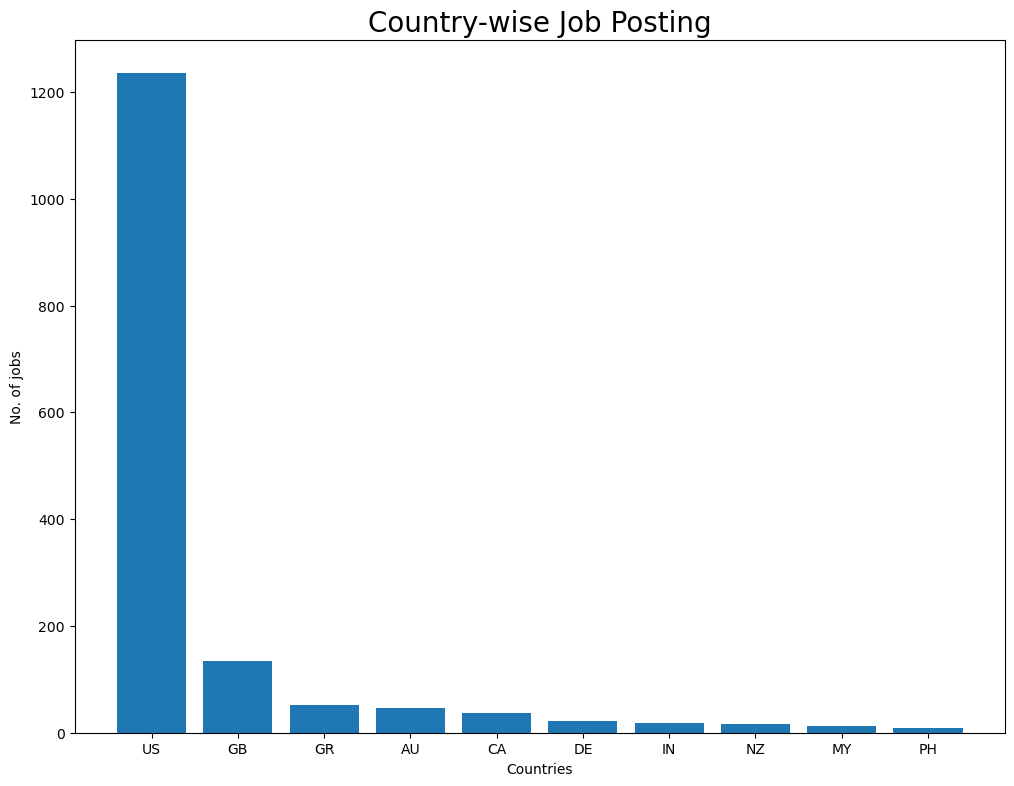

In [ ]:
# creating a dictionary(key-value pair) with top 10 country
country = dict(df.country.value_counts()[:11])
del country[' '] #deleting country with space values
plt.figure(figsize=(12,9))
plt.title('Country-wise Job Posting', size=20)
plt.bar(country.keys(), country.values()) #(xaxis,yaxis)
plt.ylabel('No. of jobs', size=10)
plt.xlabel('Countries', size=10)


In [ ]:
country.keys()
# Get all the keys (column names or index labels) from the country object

dict_keys(['US', 'GB', 'GR', 'AU', 'CA', 'DE', 'IN', 'NZ', 'MY', 'PH'])

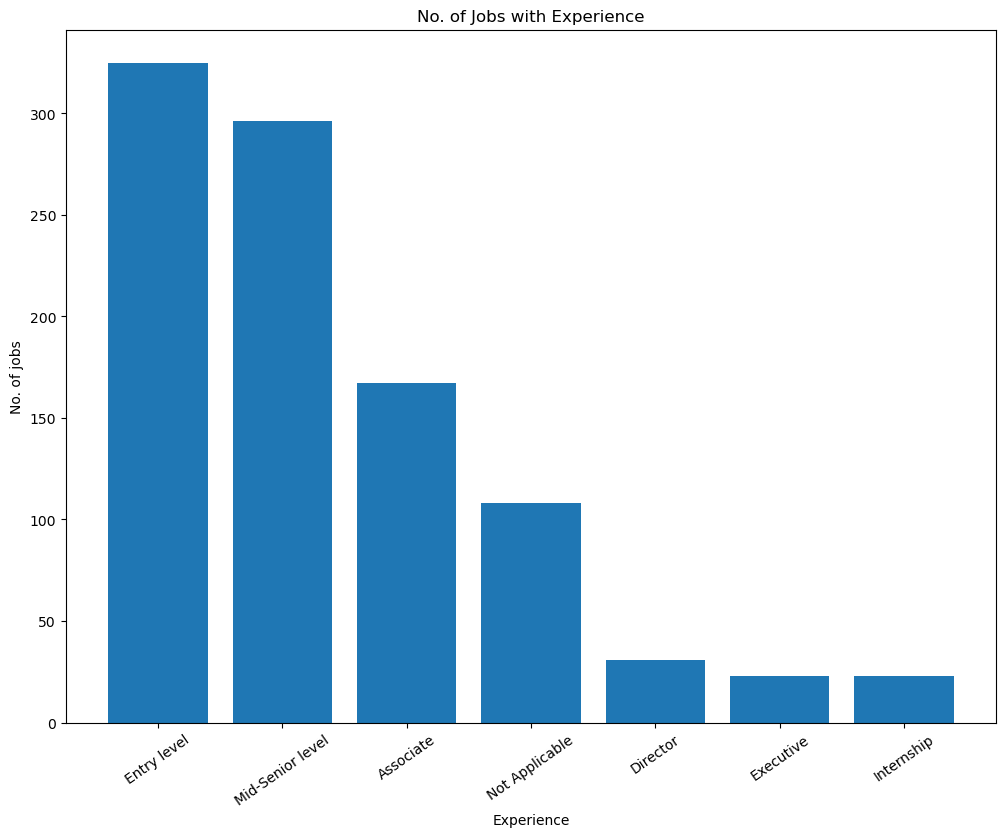

In [ ]:
# visualizing jobs based on experience
experience = dict(df.required_experience.value_counts())
del experience[' ']
plt.figure(figsize=(12,9))
plt.bar(experience.keys(), experience.values())
plt.title('No. of Jobs with Experience')
plt.xlabel('Experience', size=10)
plt.ylabel('No. of jobs', size=10)
plt.xticks(rotation=35)
plt.show()

In [ ]:
# Task: This data is Inbalanced, it contains 95% of real jobs and only 5% fake jobs,but we can make it balance
# Try this out
#Most frequent jobs
print(df.title.value_counts()[:10])


title
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Cruise Staff Wanted *URGENT*                                            21
Data Entry Admin/Clerical Positions - Work From Home                    21
Customer Service Representative                                         19
Administrative Assistant                                                16
English Teacher Abroad                                                  14
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Graduates: English Teacher Abroad (Conversational)                      11
Payroll Clerk                                                           10
Network Marketing                                                       10
Name: count, dtype: int64


In [ ]:
#Titles and count of fraudulent jobs
# checking for most fake jobs based on title
print(df[df.fraudulent==1].title.value_counts()[:10])

title
Data Entry Admin/Clerical Positions - Work From Home                    21
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Cruise Staff Wanted *URGENT*                                            21
Customer Service Representative                                         17
Administrative Assistant                                                16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Account Sales Managers $80-$130,000/yr                                  10
Network Marketing                                                       10
Payroll Clerk                                                           10
Payroll Data Coordinator Positions - Earn $100-$200 Daily               10
Name: count, dtype: int64


In [ ]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country
553,554,Misc Applications,,,,"We're an emerging technology agency, and we bu...",Candidates that have applied to MM through var...,,,0,1,0,,,,,,0,
8390,8391,Telemarketers Needed,"US, CA, Los Angeles",,,We are a digital marketing agency with an emph...,We are seeking experienced telemarketers only....,Backgrounds in these areas work well in this p...,Flexible ShiftsWorld Class Training!Pay Twice ...,0,1,1,Full-time,Associate,High School or equivalent,Marketing and Advertising,Sales,0,US
2065,2066,Managing Director,"CA, BC, Vancouver",,,Pardon Services Canada is a national legal ser...,"Pardon Services Canada, established in 1989, i...",Experience: At least five years operations man...,,0,1,1,,,,,,0,CA
16098,16099,Digital Designer for a Venture Capital Company,"GB, LND, London",,28000-35000,"Based in Hoxton, London, Forward Partners are ...",Forward Partners is an ecommerce investment st...,THE ROLETo work closely with the Head of Produ...,,0,1,0,Full-time,Associate,Unspecified,Internet,Art/Creative,0,GB
9020,9021,Front-End Developer,"IT, 25, Milano",Development,25000-31000,we are a digital creative studio focused on UX...,Moze is looking for talented developers to del...,3+ years of relevant work experience.Deep know...,MacBook Air.Workstation desk and meeting rooms...,0,1,1,Full-time,Mid-Senior level,Unspecified,Information Technology and Services,Information Technology,0,IT


### DESCRIPTIVE STATISTICS

In [ ]:
# Split salary range into min and max
df[['min_salary', 'max_salary']] = df['salary_range'].str.split('-', expand=True)

# Convert to numeric
df['min_salary'] = pd.to_numeric(df['min_salary'], errors='coerce')
df['max_salary'] = pd.to_numeric(df['max_salary'], errors='coerce')

# Create average salary column
df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

df[['min_salary', 'max_salary', 'avg_salary']].head()

,min_salary,max_salary,avg_salary
553,NaN,NaN,NaN
8390,NaN,NaN,NaN
2065,NaN,NaN,NaN
16098,28000.0,35000.0,31500.0
9020,25000.0,31000.0,28000.0


In [ ]:
#Mean Salary
mean_salary = df['avg_salary'].mean()
print("Mean Salary:", mean_salary)

Mean Salary: 2960790.116045845


In [ ]:
#Median Salary
median_salary = df['avg_salary'].median()
print("Median Salary:", median_salary)

# Standard Deviation
std_salary = df['avg_salary'].std()
print("Standard Deviation:", std_salary)

Median Salary: 38000.0
Standard Deviation: 53525263.56582629


In [ ]:
# Min / Max Salary
print("Minimum Salary:", df['avg_salary'].min())
print("Maximum Salary:", df['avg_salary'].max())

#Variance
variance_salary = df['avg_salary'].var()
print("Variance:", variance_salary)

Minimum Salary: 0.0
Maximum Salary: 1000000000.0
Variance: 2864953839791171.5


In [ ]:
#Skewness
skewness = df['avg_salary'].skew()
print("Skewness:", skewness)

# Kurtosis
kurtosis = df['avg_salary'].kurt()
print("Kurtosis:", kurtosis)

Skewness: 18.67984804941946
Kurtosis: 348.9575061044892


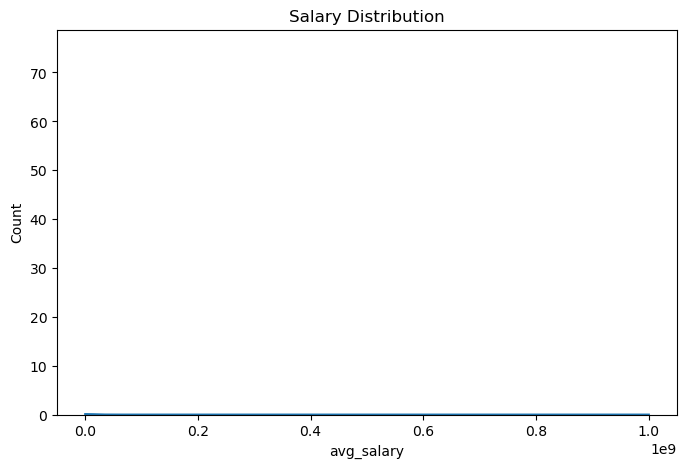

In [ ]:
#Distribution Plot (Histogram + KDE)
plt.figure(figsize=(8,5))
sns.histplot(df['avg_salary'], kde=True)
plt.title("Salary Distribution")
plt.show()


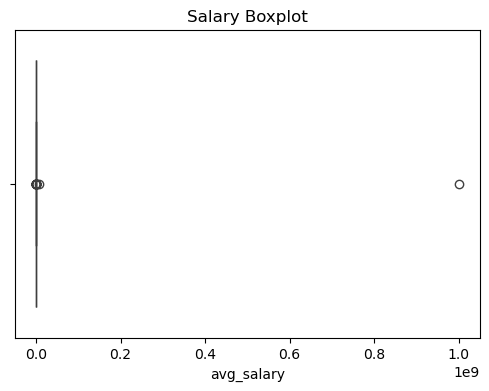

In [ ]:
#Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['avg_salary'])
plt.title("Salary Boxplot")
plt.show()

In [ ]:
#Frequency Table (Percentage)
freq_percent = df['employment_type'].value_counts(normalize=True) * 100
print(freq_percent)

employment_type
Full-time    62.702079
             22.517321
Contract      6.351039
Part-time     6.177829
Other         1.443418
Temporary     0.808314
Name: proportion, dtype: float64


In [ ]:
# Count the frequency of each unique value in the 'employment_type' column
df['employment_type'].value_counts()

employment_type
Full-time    1086
              390
Contract      110
Part-time     107
Other          25
Temporary      14
Name: count, dtype: int64

In [ ]:
#Mode of Categorical Variables
mode_emp = df['employment_type'].mode()[0]
print("Mode (Most Common Employment Type):", mode_emp)

Mode (Most Common Employment Type): Full-time


In [ ]:
df['avg_salary'].describe()

count    3.490000e+02
mean     2.960790e+06
std      5.352526e+07
min      0.000000e+00
25%      2.250000e+04
50%      3.800000e+04
75%      6.750000e+04
max      1.000000e+09
Name: avg_salary, dtype: float64

### EDA

In [ ]:
# Basic Preprocessing (important for queries)
df['salary_range'] = df['salary_range'].fillna('0-0')
df['company_profile'] = df['company_profile'].fillna('')
df['description'] = df['description'].fillna('')
df['location'] = df['location'].fillna('Unknown')
df['industry'] = df['industry'].fillna('Unknown')
df['employment_type'] = df['employment_type'].fillna('Unknown')

In [ ]:
#Fraud vs Employment Type
pd.crosstab(df['employment_type'], df['fraudulent'])

fraudulent,0,1
employment_type,,
,149,241
Contract,66,44
Full-time,596,490
Other,10,15
Part-time,33,74
Temporary,12,2


In [ ]:
#Fraud vs Location
df.groupby('location')['fraudulent'].mean().sort_values(ascending=False).head(10)

location
US, FL, tampa              1.0
US, MD, Abell              1.0
US, AL, Abernant           1.0
US, AL, Abbeville          1.0
US, AL,  ALEXANDER CITY    1.0
US, AK, Anchorage          1.0
US, AK,                    1.0
US, , chicago              1.0
US, , Stocton, CA          1.0
US, , San Jose             1.0
Name: fraudulent, dtype: float64

In [ ]:
#Fraud vs Industry
df.groupby('industry')['fraudulent'].mean().sort_values(ascending=False).head(10)

industry
Food Production                    1.0
Ranching                           1.0
Wholesale                          1.0
Animation                          1.0
Military                           1.0
Executive Office                   1.0
Investment Management              1.0
Outsourcing/Offshoring             1.0
Defense & Space                    1.0
Business Supplies and Equipment    1.0
Name: fraudulent, dtype: float64

In [ ]:
# Fraud vs Salary - Fixed version
df['salary_avg'] = df['salary_range'].str.split('-').apply(
    lambda x: (int(x[0]) + int(x[1]))/2
    if len(x) == 2 and x[0].isdigit() and x[1].isdigit()
    else 0
)

df.groupby('fraudulent')['salary_avg'].mean()

fraudulent
0    1.164193e+06
1    2.901213e+04
Name: salary_avg, dtype: float64

In [ ]:
#Fraud vs Company Profile Presence
df['has_company_profile'] = df['company_profile'].apply(lambda x: 0 if x=='' else 1)

pd.crosstab(df['has_company_profile'], df['fraudulent'], normalize='index')

fraudulent,0,1
has_company_profile,,
1,0.5,0.5


In [ ]:
#Fraud vs Description Length
df['desc_len'] = df['description'].apply(len)

df.groupby('fraudulent')['desc_len'].mean()

fraudulent
0    1194.105081
1    1154.836028
Name: desc_len, dtype: float64

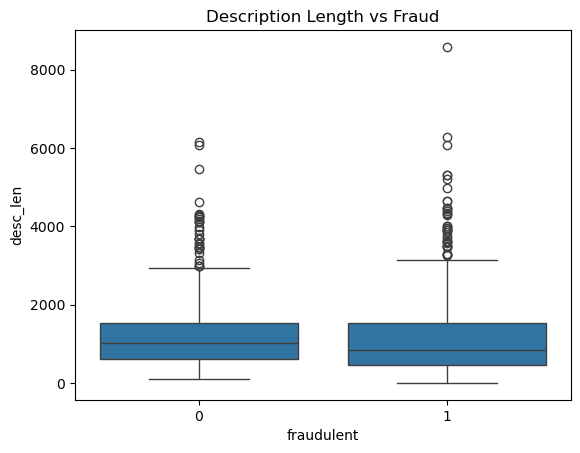

In [ ]:
#Description Length vs Fraud
sns.boxplot(x='fraudulent', y='desc_len', data=df)
plt.title("Description Length vs Fraud")
plt.show()

In [ ]:
#Fake Jobs with Missing Company Info
df[(df['fraudulent']==1) & (df['company_profile']=='')].shape

(0, 25)

In [ ]:
#Fake Jobs with High Salary
df[(df['fraudulent']==1) & (df['salary_avg']>100000)].head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,industry,function,fraudulent,country,min_salary,max_salary,avg_salary,salary_avg,has_company_profile,desc_len
98,99,IC&E Technician,"US, , Stocton, CA",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abilitie...",BENEFITSWhat is offered:Competitive compensati...,0,...,Oil & Energy,Other,1,US,95000.0,115000.0,105000.0,105000.0,1,2245
215,216,IC&E Technician Mt Poso,"US, CA, Bakersfield, CA / Mt. Poso",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abiliti...",BENEFITSWhat is offered:Competitive compensati...,0,...,Oil & Energy,Other,1,US,95000.0,115000.0,105000.0,105000.0,1,2246
2892,2893,Marketing Database Decision Strategy Consultant,"US, CA, San Francisco",,80000-200000,,Looking for a modeling manager who is self-sta...,Preferred Skills Experience with SAS E-Miner o...,Salary: 180kIf you have all the necesary skill...,0,...,Marketing and Advertising,Strategy/Planning,1,US,80000.0,200000.0,140000.0,140000.0,1,2807
5073,5074,Junior Engineer/Engineering Technician,"US, CA, San Jose","Engineering, Pipeline Design",6266624-8582080,,"Founded in 1866, San Jose Water Company is an...",Required Knowledge and Skills:Useful and profi...,San Jose Water Company offers a very comprehen...,0,...,Utilities,Engineering,1,US,6266624.0,8582080.0,7424352.0,7424352.0,1,1307
5687,5688,Network Marketing,"US, TX,",,7200-1380000,,"Are you looking to make anywhere from 600-115,...","An ambition to succeed, A desire to be the bes...","Residual Income, Travel dollars, Car Dollars, ...",0,...,Marketing and Advertising,Advertising,1,US,7200.0,1380000.0,693600.0,693600.0,1,587


In [ ]:
#Top 10 Suspicious Job Titles
df[df['fraudulent']==1]['title'].value_counts().head(10)

title
Data Entry Admin/Clerical Positions - Work From Home                    21
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Cruise Staff Wanted *URGENT*                                            21
Customer Service Representative                                         17
Administrative Assistant                                                16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Account Sales Managers $80-$130,000/yr                                  10
Network Marketing                                                       10
Payroll Clerk                                                           10
Payroll Data Coordinator Positions - Earn $100-$200 Daily               10
Name: count, dtype: int64

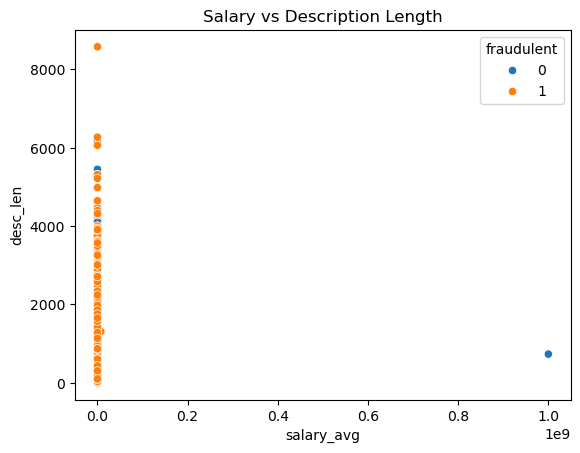

In [ ]:
#Scatter: Salary vs Description Length
sns.scatterplot(x='salary_avg', y='desc_len', hue='fraudulent', data=df)
plt.title("Salary vs Description Length")
plt.show()

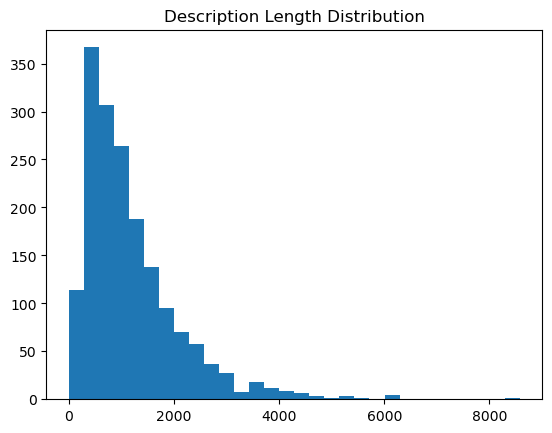

In [ ]:
#Histogram of Description Length
plt.hist(df['desc_len'], bins=30)
plt.title("Description Length Distribution")
plt.show()

In [ ]:
#Fraud Trend by Region
df.groupby('country')['fraudulent'].mean().sort_values(ascending=False).head(10)

country
TW    1.000000
BH    1.000000
QA    1.000000
SA    1.000000
MY    0.923077
AU    0.851064
US    0.590615
ID    0.500000
      0.475000
PL    0.375000
Name: fraudulent, dtype: float64

In [ ]:
#Word Frequency in Fake Jobs
from collections import Counter

fake_words = ' '.join(df[df['fraudulent']==1]['description']).split()
Counter(fake_words).most_common(10)

[('and', 7870),
 ('to', 4141),
 ('the', 3894),
 ('of', 2741),
 ('a', 2262),
 ('in', 2126),
 ('for', 1978),
 ('with', 1733),
 ('are', 1130),
 ('is', 1127)]

In [ ]:
#Word Frequency in Real Jobs
real_words = ' '.join(df[df['fraudulent']==0]['description']).split()
Counter(real_words).most_common(10)

[('and', 8366),
 ('to', 4658),
 ('the', 4174),
 ('of', 3237),
 ('a', 2980),
 ('in', 2527),
 ('for', 2287),
 ('with', 1945),
 ('our', 1398),
 ('is', 1358)]

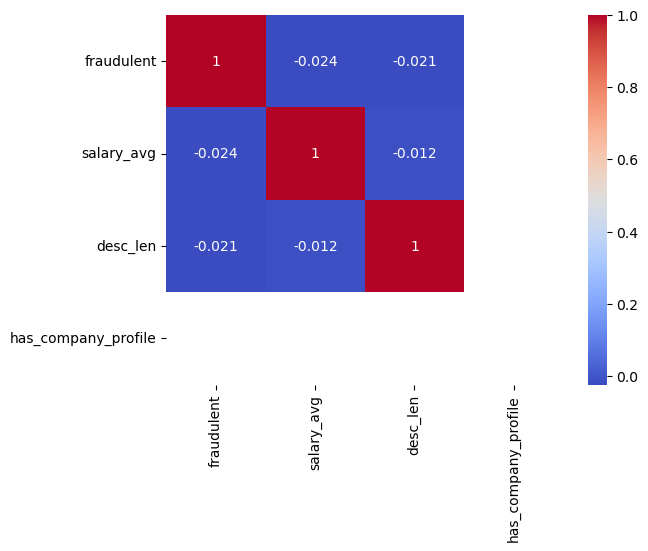

In [ ]:
#Correlation Heatmap
num_df = df[['fraudulent','salary_avg','desc_len','has_company_profile']]

sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Feature Importance (Basic - Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = num_df.drop('fraudulent', axis=1)
y = num_df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

salary_avg             0.000002
desc_len              -0.000025
has_company_profile   -0.021716
dtype: float64

### Statistical testing

In [ ]:
#Chi-square: Employment Type vs Fraud
from scipy.stats import chi2_contingency

table = pd.crosstab(df['employment_type'], df['fraudulent'])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("P-value:", p)


Chi2: 60.30192629696941
P-value: 1.0527862236227653e-11


In [ ]:
#Chi-square: Industry vs Fraud
table = pd.crosstab(df['industry'], df['fraudulent'])
chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 1.0898320912894978e-61


In [ ]:
#T-test: Salary vs Fraud
from scipy.stats import ttest_ind

real = df[df['fraudulent']==0]['salary_avg']
fake = df[df['fraudulent']==1]['salary_avg']

t_stat, p = ttest_ind(real, fake, nan_policy='omit') #Checks if salary differs between fake & real jobs

print("T-stat:", t_stat)
print("P-value:", p)

T-stat: 0.9830452591700866
P-value: 0.3257226208196846


In [ ]:
#ANOVA: Salary Across Industries
from scipy.stats import f_oneway

groups = [group['salary_avg'].dropna() for name, group in df.groupby('industry')]

f_stat, p = f_oneway(*groups)

print("P-value:", p)

#Tests if salary varies across industries

P-value: 3.593058621198243e-91


In [ ]:
#Correlation Test
from scipy.stats import pearsonr

corr, p = pearsonr(df['salary_avg'], df['desc_len'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: -0.011635769861089839
P-value: 0.6284453780309948


In [ ]:
#Hypothesis Test on Description Length
real = df[df['fraudulent']==0]['desc_len']
fake = df[df['fraudulent']==1]['desc_len']

t_stat, p = ttest_ind(real, fake)

print("P-value:", p)

#Checks if fake jobs have different description lengths

P-value: 0.3751733251864986


In [ ]:
#P-value Interpretation (Simple Logic)
if p < 0.05:
    print("Reject Null Hypothesis (Significant)")
else:
    print("Fail to Reject Null (Not Significant)")

Fail to Reject Null (Not Significant)


In [ ]:
#Confidence Interval (Salary Mean)
import scipy.stats as stats

mean = df['salary_avg'].mean()
sem = stats.sem(df['salary_avg'])

ci = stats.t.interval(0.95, len(df['salary_avg'])-1, loc=mean, scale=sem)

print("95% CI:", ci)

95% CI: (-535821.8473914876, 1729027.1020104252)


In [ ]:
#Logistic Regression Coefficient Significance
import statsmodels.api as sm

X = df[['salary_avg','desc_len','has_company_profile']]
y = df['fraudulent']

X = sm.add_constant(X)

model = sm.Logit(y, X).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.692542
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             fraudulent   No. Observations:                 1732
Model:                          Logit   Df Residuals:                     1729
Method:                           MLE   Df Model:                            2
Date:                Tue, 26 May 2026   Pseudo R-squ.:               0.0008737
Time:                        10:24:50   Log-Likelihood:                -1199.5
converged:                       True   LL-Null:                       -1200.5
Covariance Type:            nonrobust   LLR p-value:                    0.3503
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
salary_avg          -4.783e-09   1.09e-08     -0.439      0.661   -2.61e-08    1.66e-08
desc_len            -4.699e-05   5.23e-05     -0.898      0.369      -0.000    5.55e-05
has_company_profile     0.0564      0.078      0.723      0.469      -0.096       0.209
=======================================================================================
"""

In [ ]:
#Odds Ratio Interpretation
import numpy as np

odds_ratios = np.exp(model.params)
print(odds_ratios)

salary_avg             1.000000
desc_len               0.999953
has_company_profile    1.058032
dtype: float64


### Machine learning

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['salary_avg','desc_len','has_company_profile']]
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
#Naive Bayes Model
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [ ]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
#Accuracy Comparison
from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, y_pred_lr))
print("NB:", accuracy_score(y_test, y_pred_nb))
print("RF:", accuracy_score(y_test, y_pred_rf))

LR: 0.49279538904899134
NB: 0.5072046109510087
RF: 0.69164265129683


In [ ]:
#Precision, Recall, F1-score
from sklearn.metrics import classification_report

print("Logistic Regression\n", classification_report(y_test, y_pred_lr))

Logistic Regression
               precision    recall  f1-score   support

           0       0.49      1.00      0.66       171
           1       0.00      0.00      0.00       176

    accuracy                           0.49       347
   macro avg       0.25      0.50      0.33       347
weighted avg       0.24      0.49      0.33       347



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[119  52]
 [ 55 121]]


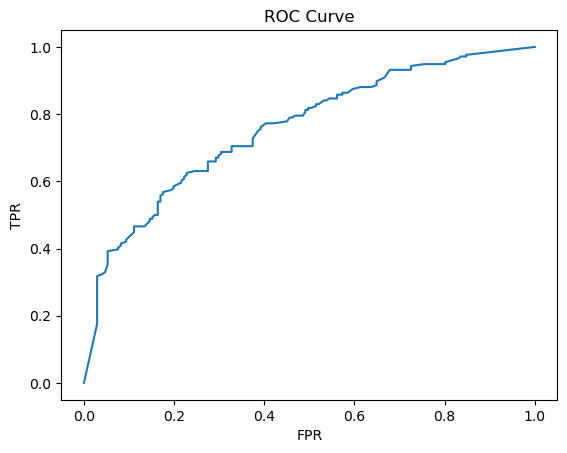

In [ ]:
#ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [ ]:
#AUC Score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.7582735247208932


In [ ]:
#Feature Importance Ranking
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

desc_len               0.885176
salary_avg             0.114824
has_company_profile    0.000000
dtype: float64


In [ ]:
#Cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)
print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.6726174809681665


In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators':[50,100],
              'max_depth':[5,10]}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [ ]:
#Overfitting Check
train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Train:", train_acc)
print("Test:", test_acc)

Train: 0.9516245487364621
Test: 0.69164265129683


In [ ]:
#Train vs Test Accuracy
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9516245487364621
Test Accuracy: 0.69164265129683


In [ ]:
#Model Comparison Table
results = pd.DataFrame({
    'Model':['LR','NB','RF'],
    'Accuracy':[accuracy_score(y_test,y_pred_lr),
                accuracy_score(y_test,y_pred_nb),
                accuracy_score(y_test,y_pred_rf)]
})

print(results)

  Model  Accuracy
0    LR  0.492795
1    NB  0.507205
2    RF  0.691643


In [ ]:
#Final Model Selection
best_model = results.sort_values(by='Accuracy', ascending=False)
print(best_model)

  Model  Accuracy
2    RF  0.691643
1    NB  0.507205
0    LR  0.492795


### Fraud risk score

In [ ]:
#Predict Probabilities
# Using Random Forest (best model usually)
y_prob = rf.predict_proba(X_test)[:,1]

# Add to dataframe
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Fraud_Prob'] = y_prob

results_df.head()

,salary_avg,desc_len,has_company_profile,Actual,Fraud_Prob
6287,0.0,2700,1,1,0.96
710,130000.0,1130,1,0,0.37
6350,0.0,1498,1,0,0.88
17699,0.0,577,1,1,1.00
17556,0.0,3257,1,1,0.88


In [ ]:
#Convert to Percentage
results_df['Fraud_Percentage'] = results_df['Fraud_Prob'] * 100
results_df[['Fraud_Prob','Fraud_Percentage']].head()

,Fraud_Prob,Fraud_Percentage
6287,0.96,96.0
710,0.37,37.0
6350,0.88,88.0
17699,1.00,100.0
17556,0.88,88.0


In [ ]:
#Categorize Risk
def risk_category(x):
    if x < 30:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

results_df['Risk_Level'] = results_df['Fraud_Percentage'].apply(risk_category)

results_df[['Fraud_Percentage','Risk_Level']].head()

,Fraud_Percentage,Risk_Level
6287,96.0,High
710,37.0,Medium
6350,88.0,High
17699,100.0,High
17556,88.0,High


In [ ]:
#Visualize Risk Distribution

#To generate actual values from your data:

results_df['Risk_Level'].value_counts()

Risk_Level
High      134
Low       130
Medium     83
Name: count, dtype: int64

In [ ]:
#Top High-Risk Jobs
high_risk_jobs = results_df[results_df['Risk_Level']=="High"]

# Show top 10 highest probability jobs
high_risk_jobs.sort_values(by='Fraud_Prob', ascending=False).head(10)

,salary_avg,desc_len,has_company_profile,Actual,Fraud_Prob,Fraud_Percentage,Risk_Level
17811,0.0,565,1,1,1.0,100.0,High
17593,0.0,862,1,1,1.0,100.0,High
3189,0.0,577,1,1,1.0,100.0,High
17742,0.0,862,1,1,1.0,100.0,High
17746,693600.0,587,1,1,1.0,100.0,High
6851,693600.0,587,1,1,1.0,100.0,High
17590,0.0,577,1,1,1.0,100.0,High
17756,0.0,33,1,1,1.0,100.0,High
17602,693600.0,587,1,1,1.0,100.0,High
17767,0.0,862,1,1,1.0,100.0,High


### Advance NLP tasks

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Create and fit TfidfVectorizer (assuming df exists)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf.fit(df['description'].fillna(''))  # Fit on all descriptions
#Top Keywords in Fake Jobs

fake_tfidf = tfidf.transform(df[df['fraudulent']==1]['description'])
mean_scores = np.asarray(fake_tfidf.mean(axis=0)).ravel()
keywords_fake = pd.Series(mean_scores, index=tfidf.get_feature_names_out())
keywords_fake.sort_values(ascending=False).head(10)

work          0.053867
time          0.039858
amp           0.039539
position      0.035586
skills        0.033322
customer      0.033135
service       0.031071
experience    0.030839
data          0.029553
home          0.028849
dtype: float64

In [ ]:
#Top Keywords in Real Jobs
real_tfidf = tfidf.transform(df[df['fraudulent']==0]['description'])

mean_scores = np.asarray(real_tfidf.mean(axis=0)).ravel()
keywords_real = pd.Series(mean_scores, index=tfidf.get_feature_names_out())

keywords_real.sort_values(ascending=False).head(10)

team           0.049176
sales          0.036272
customer       0.034145
experience     0.033555
looking        0.032934
work           0.032374
business       0.031569
marketing      0.030112
development    0.029972
product        0.029233
dtype: float64

In [ ]:
# For textual type data we will try to create word cloud
# but before that we will try to create text combining all the data present in
# our database.
df['text'] = df['title']+' '+df['location']+' '+df['company_profile']+' '+df['description']+' '+df['requirements']+' '+df['benefits']+' '+df['industry']

del df['title']
del df['location']
del df['department']
del df['company_profile']
del df['description']
del df['requirements']
del df['benefits']
del df['required_experience']
del df['required_education']
del df['industry']
del df['function']
del df['country']
del df['employment_type']


In [ ]:
df.head()

,job_id,salary_range,telecommuting,has_company_logo,has_questions,fraudulent,min_salary,max_salary,avg_salary,salary_avg,has_company_profile,desc_len,text
553,554,,0,1,0,0,NaN,NaN,NaN,0.0,1,106,Misc Applications We're an emerging technolo...
8390,8391,,0,1,1,0,NaN,NaN,NaN,0.0,1,1281,"Telemarketers Needed US, CA, Los Angeles We ar..."
2065,2066,,0,1,1,0,NaN,NaN,NaN,0.0,1,4248,"Managing Director CA, BC, Vancouver Pardon Ser..."
16098,16099,28000-35000,0,1,0,0,28000.0,35000.0,31500.0,31500.0,1,691,Digital Designer for a Venture Capital Company...
9020,9021,25000-31000,0,1,1,0,25000.0,31000.0,28000.0,28000.0,1,491,"Front-End Developer IT, 25, Milano we are a di..."


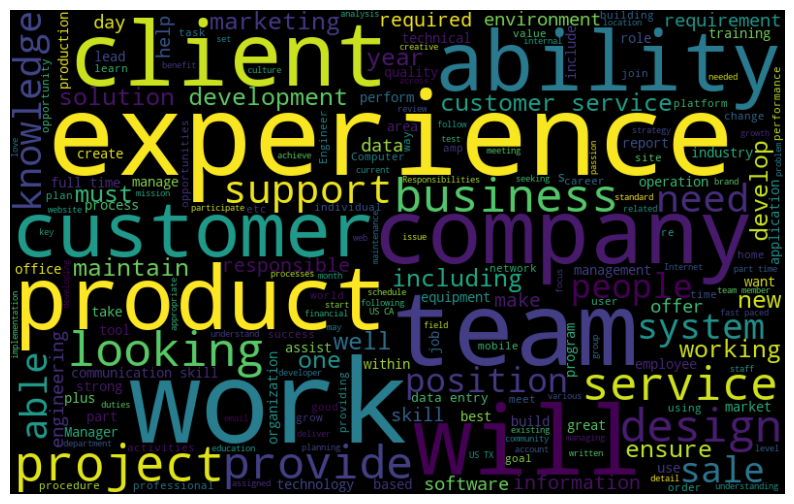

In [ ]:
# we will plot 3 kind of word cloud
# 1st we will visualize all the words our data using the wordcloud plot
# 2nd we will visualize common words in real job posting
# 3rd we will visualize common words in fraud job posting
# join function is a core python function
from wordcloud import WordCloud
all_words = ''.join([text for text in df["text"]])


wordcloud = WordCloud(width = 800, height = 500, random_state=21, max_font_size=120).generate(all_words)


plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



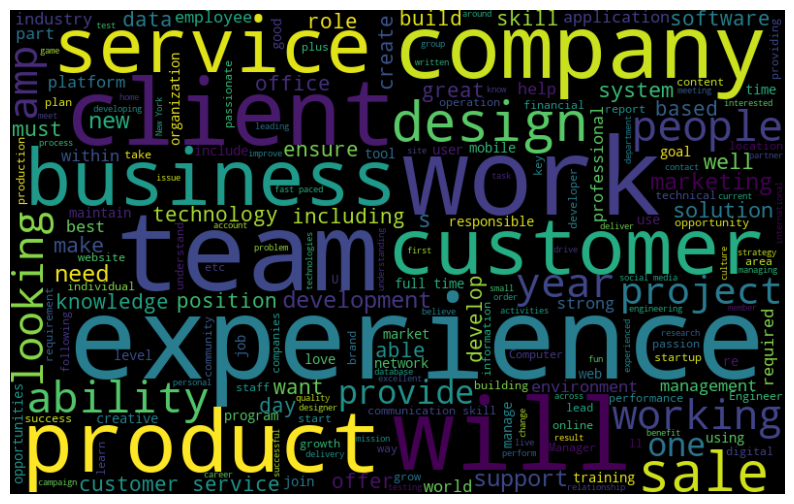

In [ ]:
# Common words in real job posting texts

real_post = ''.join([text for text in df["text"][df['fraudulent']==0]])
wordcloud = WordCloud(width = 800, height = 500, random_state=21, max_font_size=120).generate(real_post)



plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



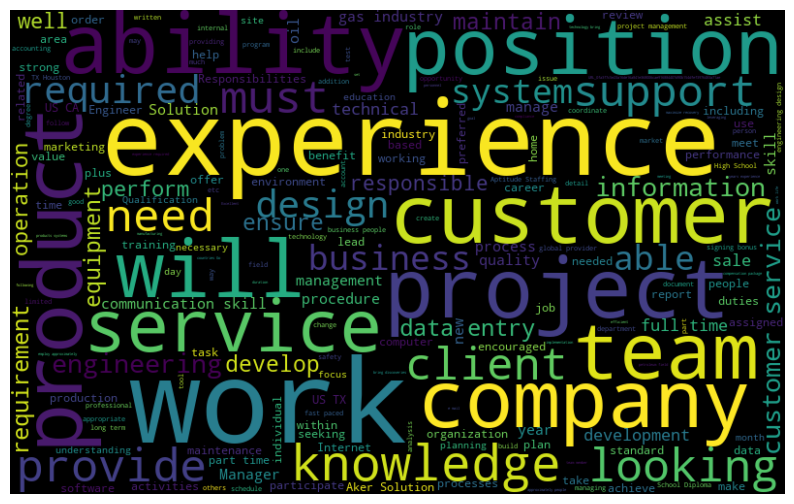

In [ ]:
# Common words in fraud job posting texts

fraud_post = ''.join([text for text in df["text"][df['fraudulent'] == 1]])


wordcloud = WordCloud(width = 800, height = 500, random_state=21, max_font_size=120).generate(fraud_post)


plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()



In [ ]:
# NLTK :: Natural Language Toolkit
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mohammedabdulwahed/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
#loading the stopwords
stop_words = set(stopwords.words("english"))


In [ ]:
#converting all the text to lower case
df['text'] = df['text'].apply(lambda x:x.lower())


In [ ]:
#removing the stop words from the corpus
df['text'] = df['text'].apply(lambda x:' '.join([word for word in x.split() if word not in (stop_words)]))


In [ ]:
# Check if DataFrame has data and column exists before accessing
if not df.empty and 'text' in df.columns and len(df) > 0:
    df['text'].iloc[0]  # Use .iloc[0] for safer indexing
else:
    print("DataFrame is empty or 'text' column doesn't exist")

In [ ]:
print(df['text'].iloc[0])

misc applications emerging technology agency, build breakthrough products user-centered design. building team brightest minds creative, engineering, business love working smart people. candidates applied mm various channels, line traditional reqs.


In [ ]:
#TEXT LENGTH ANALYSIS

#Fake jobs are usually shorter

df['text_length'] = df['text'].apply(len)

length_output = df.groupby('fraudulent')['text_length'].mean()
print("\nAverage Text Length:")
print(length_output)


Average Text Length:
fraudulent
0    2158.808314
1    1744.548499
Name: text_length, dtype: float64


In [ ]:
#KEYWORD DETECTION (FRAUD FILTER)

#Simple rule-based fraud detection

fraud_keywords = [
    'easy money', 'quick money', 'no experience',
    'work from home', 'earn cash', 'urgent hiring'
]

def keyword_flag(text):
    text = str(text).lower()
    return any(word in text for word in fraud_keywords)

df['keyword_flag'] = df['text'].apply(keyword_flag)

keyword_output = pd.crosstab(df['keyword_flag'], df['fraudulent'])

print("\nKeyword Detection Table:")
print(keyword_output)


Keyword Detection Table:
fraudulent      0    1
keyword_flag          
False         865  832
True            1   34


In [ ]:
from sklearn.model_selection import train_test_split
# Splitting dataset in train and test
X_train, X_test, y_train, y_test = train_test_split(df.text, df.fraudulent, test_size=0.3)


# what does X-train and y_train contain
print(y_train)
print(X_train)



6695     1
17787    1
1995     1
6959     0
9417     0
        ..
9117     1
11879    0
15913    0
3409     0
11766    1
Name: fraudulent, Length: 1212, dtype: int64
6695     cruise staff wanted *urgent* us, pa, philadelp...
17787    cash paying vacancies (apply today) us, ca, lo...
1995     customer service/ data entry us, al, alexander...
6959     oracle financials ph, 00, quezon city collaber...
9417     outside sales representative us, wi, milwaukee...
                               ...                        
9117     business operations associate us, ks, overland...
11879    sales us, fl, fort lauderdale spotsource solut...
15913    electrical maintenance technician - major stat...
3409     digital planner nz, n, auckland young &amp; sh...
11766    customer success district manager us, mo, st. ...
Name: text, Length: 1212, dtype: object


In [ ]:
# The model cannot operate text data so we need to convert our data into vector format
# we will be using Bag of words model
from sklearn.feature_extraction.text import CountVectorizer

#  instantiate the vectorizer
vect = CountVectorizer()

# learn training data vocabulary, then use it to create a document-term matrix
# fit
vect.fit(X_train)

# transform training data
X_train_dtm = vect.transform(X_train)



# examine the document-term matrix
X_train_dtm

#how X_train_dtm is looking
print(X_train_dtm)
# This is Matrix representation,non 0 valued cells are not printed

  (0, 220)	1
  (0, 515)	1
  (0, 582)	2
  (0, 757)	1
  (0, 789)	1
  (0, 821)	1
  (0, 854)	1
  (0, 1098)	1
  (0, 1134)	1
  (0, 1149)	13
  (0, 1363)	1
  (0, 1395)	1
  (0, 1505)	1
  (0, 1880)	1
  (0, 2030)	1
  (0, 2180)	2
  (0, 2356)	4
  (0, 2396)	1
  (0, 2438)	1
  (0, 2811)	1
  (0, 2814)	1
  (0, 3052)	2
  (0, 3309)	1
  (0, 3635)	1
  (0, 3666)	2
  :	:
  (1211, 18480)	1
  (1211, 18552)	1
  (1211, 18907)	2
  (1211, 18921)	1
  (1211, 18928)	1
  (1211, 18930)	5
  (1211, 19007)	1
  (1211, 19091)	1
  (1211, 19130)	1
  (1211, 19139)	1
  (1211, 19240)	1
  (1211, 19352)	1
  (1211, 19375)	3
  (1211, 19377)	1
  (1211, 19387)	1
  (1211, 19470)	1
  (1211, 19511)	1
  (1211, 19592)	6
  (1211, 19617)	2
  (1211, 19649)	1
  (1211, 19659)	7
  (1211, 19685)	1
  (1211, 19751)	1
  (1211, 19777)	1
  (1211, 19789)	1


In [ ]:
# PCA is not advisable for a NLP task,because PCA is for
# principal feature extraction and in this case we already have features


# transform testing data (using fitted vocabulary) into a document-term matrix
X_test_dtm = vect.transform(X_test)
X_test_dtm



<520x20394 sparse matrix of type '<class 'numpy.int64'>'
	with 84019 stored elements in Compressed Sparse Row format>

### Model building and Evaluation

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Removed plot_confusion_matrix as it's deprecated in newer sklearn versions
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB

# To plot confusion matrix in newer sklearn versions, use:
# ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
# or ConfusionMatrixDisplay.from_estimator(estimator, X, y)

### Naive bayes

In [ ]:
# Naive Bayes Classifier
# we are using Multinomial Naive Bayes approach because the data here is not symmetrical.
# generally if there are data in the form of this long text,it is advisable to
# %time will give the time taken by the system for execution
nb = MultinomialNB()
%time nb.fit(X_train_dtm, y_train)



CPU times: user 5.87 ms, sys: 5.76 ms, total: 11.6 ms
Wall time: 10 ms


MultinomialNB()

In [ ]:
y_pred_nb = nb.predict(X_test_dtm)
print(y_pred_nb)

[0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 1 1
 0 0 1 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 1 1 0 0 0
 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1
 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0
 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0
 1 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1
 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0
 0 0 1 1 0 1 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 1 0 1 1 0 1 0 0
 1 1 0 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0
 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0
 1 0 1 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 1 1 0 1 0 1 1
 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 1
 0 0 1 0 1 0 1 1 0 1 0 1 

Classification Accuracy: 0.9153846153846154
Classification Report

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       248
           1       0.93      0.91      0.92       272

    accuracy                           0.92       520
   macro avg       0.92      0.92      0.92       520
weighted avg       0.92      0.92      0.92       520

Confusion Matrix

[[228  20]
 [ 24 248]]


Text(95.72222222222221, 0.5, 'Truth')

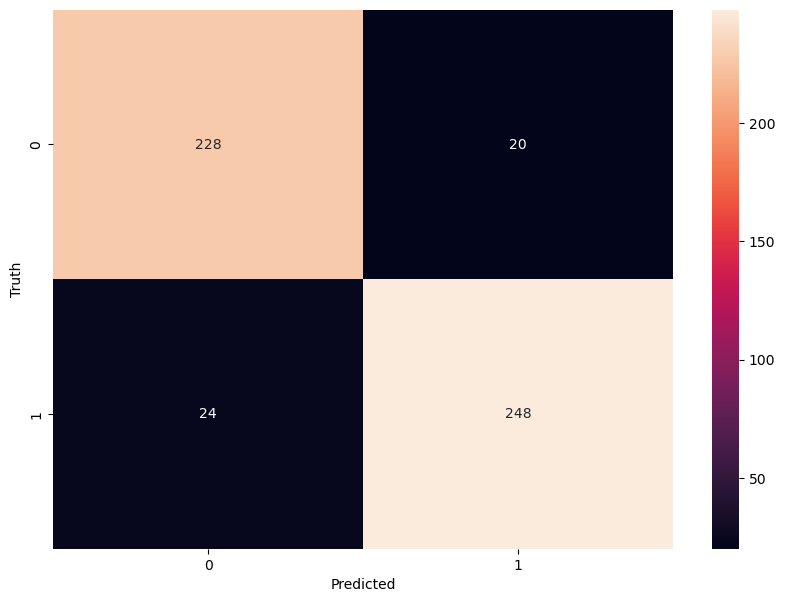

In [ ]:
accuracy_score(y_test, y_pred_nb)
print("Classification Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report\n")
print(classification_report(y_test, y_pred_nb))
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred_nb))


cm = confusion_matrix(y_test,y_pred_nb)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


### Decision tree classifier

In [ ]:
#instantiate a Decision Tree Classifier
dt = DecisionTreeClassifier()


#train the model
# using X_train_dtm (timing it with an IPython "magic command")

%time dt.fit(X_train_dtm, y_train)

CPU times: user 195 ms, sys: 7.15 ms, total: 203 ms
Wall time: 205 ms


DecisionTreeClassifier()

In [ ]:
# make class predictions for X_test_dtm
y_pred_class = dt.predict(X_test_dtm)


# Model Accuracy
print("Classification Accuracy:", accuracy_score(y_test, y_pred_class))
print("Classification Report\n")
print(classification_report(y_test, y_pred_class))
print("Confusion Matrix\n")
print(confusion_matrix(y_test, y_pred_class))



Classification Accuracy: 0.8480769230769231
Classification Report

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       248
           1       0.88      0.83      0.85       272

    accuracy                           0.85       520
   macro avg       0.85      0.85      0.85       520
weighted avg       0.85      0.85      0.85       520

Confusion Matrix

[[216  32]
 [ 47 225]]


Text(95.72222222222221, 0.5, 'Truth')

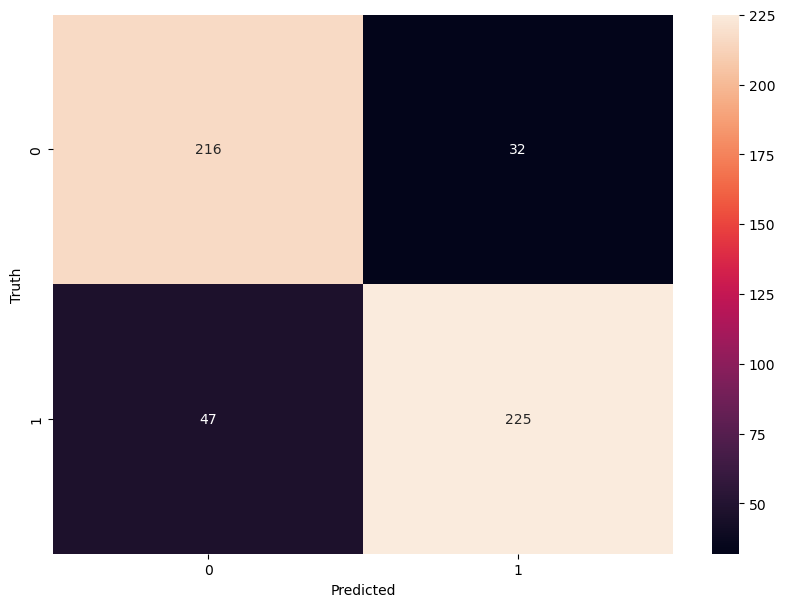

In [ ]:
# Confusion Matrix

import seaborn as sn
cm = confusion_matrix(y_test,y_pred_class)

plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


### Building a predictive system

In [ ]:
#Lets Predict for a data set
X_test


10191    customer service team lead us, ny, new york no...
8308     account manager us, ny, new york we’re always ...
2361     regional sales manager jobs california us, ca,...
17756                boys & girls club rohan fill projects
2500     corporate account executive us, ny, new york f...
                               ...                        
1974     development manager us, ca, woodland hills env...
14040    sandisk - sr. staff marketing business (pricin...
5450     retail demonstrator us, wa, seattle dyson demo...
17638    administrative assistant/office assistant us, ...
6087     environmental technician us, tx, houston choos...
Name: text, Length: 520, dtype: object

In [ ]:
print(len(X_test))

520


In [ ]:
print(X_test.iloc[105])   #  example

cdl driver-joliet us, il, joliet abc supply co., inc. nation’s largest wholesale distributor roofing one largest distributors siding, windows, exterior building products. since start 1982, grown become national organization 450 locations 45 states. mission biggest, best, easiest service company distributing exterior building products. fulfill mission stocking brands products contractors need competitive prices, operating state-of-the-art delivery system, actively listening customers. know successful customers successful. that’s make good promises every day. delivery driver, operate truck deliver building materials safe, efficient professional manner. important make deliveries schedule, also manner takes account needs contractors homeowners represents abc supply best possible light. trucks make deliveries delivery driver large heavy, must take care operate way cause damage driveways, buildings, areas job site.your specific duties delivery driver may include:conducting safe work zone job

In [ ]:
input_text=["customer service associate us, ca, san francisco novitex enterprise solutions, formerly pitney bowes management services, delivers innovative document communications management solutions help companies around world drive business process efficiencies, increase productivity, reduce costs improve customer satisfaction. almost 30 years, clients turned us integrate optimize enterprise-wide business processes empower employees, increase productivity maximize results. trusted partner, continually focus delivering secure, technology-enabled document communications solutions improve clients' work processes, enhance customer interactions drive growth. customer service associate based san francisco, ca. right candidate integral part talented team, supporting continued growth.responsibilities:perform various mail center activities (sorting, metering, folding, inserting, delivery, pickup, etc.)lift heavy boxes, files paper neededmaintain highest levels customer care demonstrating friendly cooperative attitudedemonstrate flexibility satisfying customer demands high volume, production environmentconsistently adhere business procedure guidelinesadhere safety procedurestake direction supervisor site managermaintain logs reporting documentation; attention detailparticipate cross-training perform duties assigned (filing, outgoing shipments, etc)operating mailing, copy scanning equipmentshipping & receivinghandle time-sensitive material like confidential, urgent packagesperform tasks assignedscanning incoming mail recipientsperform file purges pullscreate files ship filesprovide backfill neededenter information daily spreadsheetsidentify charges match billingsort deliver mail, small packages minimum requirements:minimum 6 months customer service related experience requiredhigh school diploma equivalent (ged) requiredpreferred qualifications:keyboarding windows environment pc skills required (word, excel powerpoint preferred)experience running mail posting equipment plusexcellent communication skills verbal writtenlifting 55 lbs without accommodationswillingness availability work additional hours assignedwillingness submit pre-employment drug screening criminal background checkability effectively work individually team environmentcompetency performing multiple functional tasksability meet employer's attendance policy computer software"]


In [ ]:
# convert text to feature vectors
input_data_features = vect.transform(input_text)

# making prediction

prediction = dt.predict(input_data_features)
print(prediction)


if (prediction[0]==1):
  print('Fraudulant Job')

else:
  print('Real Job')

[0]
Real Job


In [ ]:
#Lets check wether predicted result was correct or not
print(y_test.iloc[105])

0


In [ ]:
import random

i = random.randint(0, len(X_test)-1)
print(X_test.iloc[i])

back end engineer us, ca, san francisco flite delivers ad innovation scale world's top publishers brands. marketers use self-service flite platform reduce complexity cost delivering differentiated ad products engage audiences. flite platform serves, updates, measures advertising real-time integrates web applications directly online ad units fueling digital advertising innovation scale. flite enables marketers agile, respond immediately real-time performance metrics daily events updating paid media creatives relevant content functionality. flite's ad platform powers world's leading brands/agencies like samsung, p&amp;g, &amp; smg publishers like linkedin, forbes, &amp; conde nast. flite seeking talented, experienced back-end java engineer keep growth - sharpening key offerings well expanding fulfill current unmet needs expanding client base. great opportunity work large-scale cloud ad serving reporting back-end system fast growing, sequoia-funded startup leading change display advertisi

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)   #  FIT HERE

In [ ]:
X_test_tfidf = vectorizer.transform(X_test)   #  ONLY TRANSFORM

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # train model
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
import random # random testing

i = random.randint(0, len(X_test)-1)

print("Index:", i)

input_data = X_test.iloc[i]
print("\nJob Description:\n", input_data)

input_data = [input_data]

# IMPORTANT: use SAME fitted vectorizer
vector_input = vectorizer.transform(input_data)

prediction = model.predict(vector_input)

if prediction[0] == 0:
    print("\nPrediction: Real Job Posting")
else:
    print("\nPrediction: Fake Job Posting")

Index: 182

Job Description:
 home based payroll data entry clerk position - earn $100-$200 daily us, ga, abbeville full-service marketing staffing firm, serving companies ranging fortune 100 new start-up organizations. work job seekers equally broad range, light industrial temporary workers executive level candidates.are looking work home opportunity earn $2500 per week? online service representative position would perfect you!- set hours - make money every time decide work - work remotely home - get paid weekly - computer internet, requirementsall need access internet participate. computer internet access, valid email address, good typing skills entry level position offer full online training. need special skills get started.earn much data entry. complete training provided start working it’s easy start! ________________________________________don’t let opportunity pass by.positions still available - get started right nowif fit description meet requirements, please apply stating locat